In [85]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import weighted_average
import numpy as np
import math
import scipy.io as sp
import sys

# Directory and file names for each Matlab dataset
fb520 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_450nm_BFS-PGE-16S7M_SN22245818/Langley_plots/Band_450nm_BFS-PGE-16S7M_SN22245818_Langley_20251028_030002.mat"
fb490 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_470nm_BFS-PGE-16S7M_SN22245821/Langley_plots/Band_470nm_BFS-PGE-16S7M_SN22245821_Langley_20251028_030004.mat"
fb470 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_490nm_BFS-PGE-16S7M_SN22010605/Langley_plots/Band_490nm_BFS-PGE-16S7M_SN22010605_Langley_20251028_030003.mat"
fb450 = "/Users/jacksontobin/Local_Documents/NightTime_Research/ANGSTROM/Star_Photometry/Angstrom3_ColState/Angstrom_Overnight_2025_10_27_030000_060000/Band_520nm_BFS-PGE-16S7M_SN22011988/Langley_plots/Band_520nm_BFS-PGE-16S7M_SN22011988_Langley_20251028_030003.mat"

In [86]:
# Load each dataframe:
loc = 'all_res' # "all results" matlab file
b450 = sp.loadmat(fb450)[loc][0,:]
b450 = pd.DataFrame(b450)
b470 = sp.loadmat(fb470)[loc][0,:]
b470 = pd.DataFrame(b470)
b490 = sp.loadmat(fb490)[loc][0,:]
b490 = pd.DataFrame(b490)
b520 = sp.loadmat(fb520)[loc][0,:]
b520 = pd.DataFrame(b520)

bands = [b450, b470, b490, b520]
for i in bands:
    star_ids = i['hr']
    i['hr'] = star_ids.map(lambda x: x[0] if isinstance(x, np.uint16) else x[0][0]).values


## 1) Compute the mean AOD for each band
Raw mean and weighted mean.

In [87]:
# Compute the raw mean and std using np.polyfit
band_name = ['450nm', '470nm', '490nm', '520nm']
aod_res = []

for band, name in zip(bands, band_name):
    aod = []
    for star_id, group in band.groupby('hr'):

        # Extract Airmass and ln(DN)
        x = group['airmass'].values[0].T[0]
        y = group['log_DN'].values[0].T[0]

        # Linear regression: return slope and covariance
        p, cov = np.polyfit(x, y, 1, cov=True)
        m = p[0]
        sigma_m = np.sqrt(cov[0,0])

        # compute the weight by variance
        w = 1 / sigma_m**2

        # compute the weighted aod
        w_aod = m * w

        aod.append((m, sigma_m, w, w_aod))

    # Compute the raw AOD Mean values and standard deviation
    aod = np.array(aod)
    mean_aod = np.mean(aod[:,0])
    std_aod = np.std(aod[:,0])

    # Compute the Mean AOD using the weighted values
    weighted_mean_aod = np.sum(aod[:,3]) / np.sum(aod[:,2])
    weighted_std = 1 / np.sqrt(np.sum(aod[:,2]))
    
    aod_res.append((name, mean_aod, std_aod, weighted_mean_aod, weighted_std))

    print(f"Band: {name}")
    print(f"Mean AOD =          {mean_aod:.4f}, Std AOD =      {std_aod:.4f}")
    print(f"Weighted Mean AOD = {weighted_mean_aod:.4f}, Weighted std = {weighted_std:.4f}")    
    print()

# Create a pandas dataframe from the mean values
aod_res = pd.DataFrame(aod_res, columns=['Band', 'Mean AOD', 'Std AOD', 'Weighted Mean AOD', 'Weighted Std'])

Band: 450nm
Mean AOD =          -0.6191, Std AOD =      2.5243
Weighted Mean AOD = -0.2511, Weighted std = 0.0040

Band: 470nm
Mean AOD =          -1.4458, Std AOD =      6.9268
Weighted Mean AOD = -0.2672, Weighted std = 0.0049

Band: 490nm
Mean AOD =          -0.8428, Std AOD =      3.1523
Weighted Mean AOD = -0.2404, Weighted std = 0.0039

Band: 520nm
Mean AOD =          -1.7056, Std AOD =      3.9320
Weighted Mean AOD = -0.3865, Weighted std = 0.0055



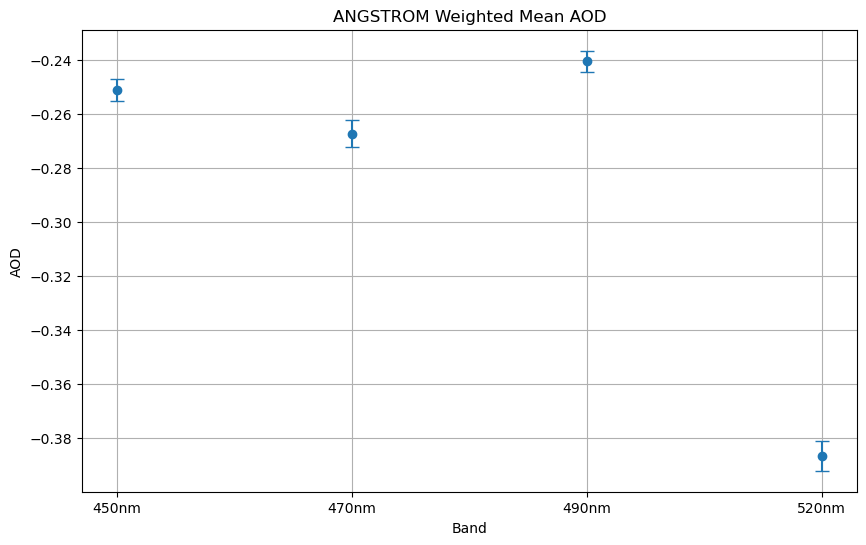

In [88]:
# Plot the aod and variances for each band:
plt.figure(figsize=(10, 6))
plt.errorbar(aod_res['Band'], aod_res['Weighted Mean AOD'], yerr=aod_res['Weighted Std'], fmt='o', label='Mean AOD', capsize=5)
plt.title('ANGSTROM Weighted Mean AOD')
plt.xlabel('Band')
plt.ylabel('AOD')
plt.grid()

## 2) Angstrom Parameter from weighted mean values
$$\alpha=\frac{\log{(\tau_1 / \tau_2)}}{\log{(\lambda_1 / \lambda_2)}}$$

In [89]:
# Compute the angstrom parameter using the previous values
lambda1 = np.array([450, 470, 490, 520])
tau = aod_res['Weighted Mean AOD'].values

# compute the angstrom parameter using adjacent bands
# tau[:-1] # from 1st to (end - 1)
# tau[1:]  # from 2nd to end
angstrom = np.log(tau[:-1] / tau[1:]) / np.log(lambda1[:-1] / lambda1[1:])
for i in range(len(angstrom)):
    band_range = f"{lambda1[:-1][i]}-{lambda1[1:][i]}nm"
    print(fr"Angstrom Exponent for {band_range}: {angstrom[i]:.4f}")

Angstrom Exponent for 450-470nm: 1.4252
Angstrom Exponent for 470-490nm: -2.5305
Angstrom Exponent for 490-520nm: 7.9854


## 3) Band-by-Band Star Comparison
- Check that any star is captured by all cameras.
- Check variance (difference) between each AOD - remove if ~too large

In [95]:
# Loop through each band and find common stars
common_stars = set(bands[0]['hr'])

for band in bands[1:]:
    common_stars.intersection_update(set(band['hr']))

print(f"Number of common stars across all bands: {len(common_stars)}")
print(common_stars)

Number of common stars across all bands: 41
{6656, 5635, 6536, 6025, 6923, 6161, 6421, 6170, 6554, 5404, 6688, 6185, 6315, 5291, 6573, 6705, 5818, 5691, 6978, 5187, 6596, 5960, 6223, 5329, 5589, 5467, 6237, 5085, 6369, 5986, 5731, 5857, 5350, 5608, 6127, 5744, 6511, 6130, 6132, 6396, 5886}


      hr                                               star  \
57  6656  [[[[[6656]], [[1030 1038 1040 1041 1044 1045 1...   

                                             frame_id  \
57  [[1030, 1038, 1040, 1041, 1044, 1045, 1046, 10...   

                                           timestamps  \
57  [[b'', b'MCOS', b'datetime', [[3707764736], [2...   

                                             elev_deg  \
57  [[18.76986806188824, 18.613303145679726, 18.57...   

                                             total_DN  \
57  [[4802.1865234375, 5451.7568359375, 3173.34790...   

                                              airmass           delta_airmass  \
57  [[3.079217173080175], [3.1036963422988206], [3...  [[0.1585003358787107]]   

                                               log_DN  \
57  [[8.476826618891787], [8.6036931909299], [8.06...   

                      slope              intercept  
57  [[-1.8265351472202025]]  [[14.26286114462982]]  
      hr                     

ValueError: x and y must have same first dimension, but have shapes (1,) and (41, 2)

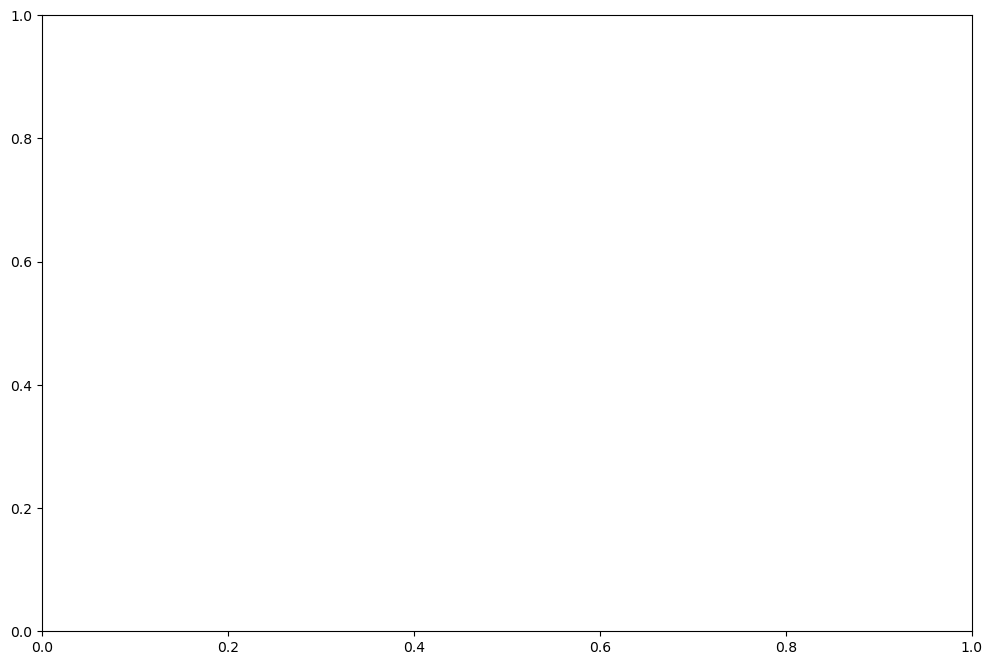

In [ ]:
# Plot the AOD values for the common stars across all bands
plt.figure(figsize=(12, 8))

for band, name in zip(bands, band_name):
    common_aod = []
    for star_id in common_stars:
        group = band[band['hr'] == star_id]
     
        x = group['airmass'].values[0].T[0]
        y = group['log_DN'].values[0].T[0]

        p, cov = np.polyfit(x, y, 1, cov=True)
        
        m = p[0]
        sigma_m = np.sqrt(cov[0,0])

        common_aod.append((m, sigma_m))

# NOTE: some kind of error here!
plt.plot(common_stars, common_aod, label=name)